# Notebook 02: Protein Characterisation Analysis

## AI-Based Identification of Novel Drug Targets for Depression

### Overview

This notebook focuses on analysing protein information associated with
depression-related genes identified in the previous stage.

The purpose of this analysis is to understand the available protein data,
evaluate the quality of protein sequences, and explore important characteristics
such as sequence length and sequence availability.

The processed protein information generated in this notebook will support
future stages of the project, including protein embedding generation,
structural analysis, and drug-target prediction.


### Research Workflow

This notebook represents the second stage of the computational workflow:

1. Analyse protein information linked to depression-associated genes.
2. Assess protein sequence quality and completeness.
3. Explore protein characteristics and sequence length distribution.
4. Prepare protein sequence data for downstream AI-based analysis.


### Dataset Description

The dataset used in this notebook is:

`protein_info.csv`

The dataset contains protein information linked to depression-associated genes,
including:

- Ensembl gene identifiers
- UniProt protein identifiers
- Protein names
- Amino acid sequences
- Protein sequence lengths


### Objectives

The main objectives of this notebook are:

1. To understand the structure and content of the protein information dataset.
2. To evaluate missing values and data quality issues within protein records.
3. To analyse protein sequence length characteristics.
4. To prepare protein sequences in a suitable format for future embedding generation.
5. To generate processed protein outputs for further analysis.

In [54]:
# 1. Import Required Libraries

import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option(
    "display.max_columns",
    None
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [55]:
# 2. Set Up Project Directories

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
# Define project directories

PROJECT_ROOT = (
    "/content/drive/MyDrive/Dissertation/"
    "Depression-Drug-Target-AI"
)


RAW_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "raw"
)


PROCESSED_DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)


FIGURE_PATH = os.path.join(
    PROJECT_ROOT,
    "figures"
)


os.makedirs(
    PROCESSED_DATA_PATH,
    exist_ok=True
)

os.makedirs(
    FIGURE_PATH,
    exist_ok=True
)


print("Project directories configured successfully.")

Project directories configured successfully.


In [57]:
# 3. Load Protein Information Dataset

protein_file = os.path.join(
    RAW_DATA_PATH,
    "protein_info.csv"
)


proteins_df = pd.read_csv(
    protein_file
)


print("Protein dataset loaded successfully.")

print(
    f"Number of protein records: {proteins_df.shape[0]}"
)

print(
    f"Number of features: {proteins_df.shape[1]}"
)

Protein dataset loaded successfully.
Number of protein records: 200
Number of features: 5


In [58]:
# 4. Explore Dataset Preview

display(
    proteins_df.head()
)

,ensembl_id,uniprot_id,protein_name,sequence,length
0,ENSG00000149295,A0A1Y8EK52,NaN,MDPLNLS,7
1,ENSG00000102468,A0A7P0PKG8,5-hydroxytryptamine receptor 2A,MHLCAISLDRYVAIQNPIHHSRFNSRTKAFLKIIAVWTISVGISMP...,308
2,ENSG00000022355,A0A1B0GU82,NaN,MRKSPGLSDCLWAWILLLSTLTGRRTSRKSHQNTDLYEVNEGKDVA...,70
3,ENSG00000183454,A0A6Q8PGD2,Glutamate receptor,MLKIMQDYDWHVFSLVTTIFPGYREFISFVKTTVDNSFVGWDMQNV...,1307
4,ENSG00000108576,P31645,Sodium-dependent serotonin transporter,METTPLNSQKQLSACEDGEDCQENGVLQKVVPTPGDKVESGQISNG...,630


In [59]:
# 5. Understand Dataset Structure

proteins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ensembl_id    200 non-null    object
 1   uniprot_id    200 non-null    object
 2   protein_name  127 non-null    object
 3   sequence      200 non-null    object
 4   length        200 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 7.9+ KB


In [60]:
# 6. Generate Statistical Summary

proteins_df.describe(
    include="all"
)

,ensembl_id,uniprot_id,protein_name,sequence,length
count,200,200,127,200,200.000000
unique,200,200,122,200,NaN
top,ENSG00000149295,A0A1Y8EK52,Glutamate receptor,MDPLNLS,NaN
freq,1,1,4,1,NaN
mean,NaN,NaN,NaN,NaN,535.995000
std,NaN,NaN,NaN,NaN,487.763324
min,NaN,NaN,NaN,NaN,7.000000
25%,NaN,NaN,NaN,NaN,193.750000
50%,NaN,NaN,NaN,NaN,423.000000
75%,NaN,NaN,NaN,NaN,643.250000


In [61]:
# 7. Assess Data Quality

missing_values = (
    proteins_df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)


missing_values

,0
protein_name,73
ensembl_id,0
uniprot_id,0
sequence,0
length,0


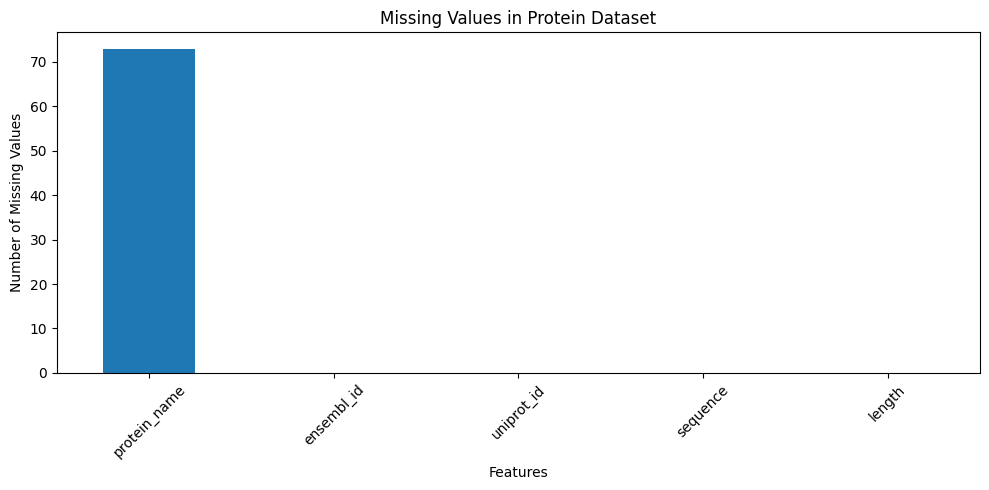

In [62]:
# 8. Analyse Missing Protein Information

plt.figure(
    figsize=(10,5)
)


missing_values.plot(
    kind="bar"
)


plt.title(
    "Missing Values in Protein Dataset"
)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Number of Missing Values"
)


plt.xticks(
    rotation=45
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "protein_missing_values.png"
    ),
    dpi=300
)


plt.show()

In [63]:
# 9. Check Duplicate Protein Records

duplicate_count = (
    proteins_df
    .duplicated()
    .sum()
)


print(
    f"Duplicate protein records: {duplicate_count}"
)

Duplicate protein records: 0


In [64]:
# 10. Analyse Protein Length Distribution

print(
    f"Average protein length: {proteins_df['length'].mean():.2f}"
)

print(
    f"Maximum protein length: {proteins_df['length'].max()}"
)

print(
    f"Minimum protein length: {proteins_df['length'].min()}"
)

Average protein length: 536.00
Maximum protein length: 3086
Minimum protein length: 7


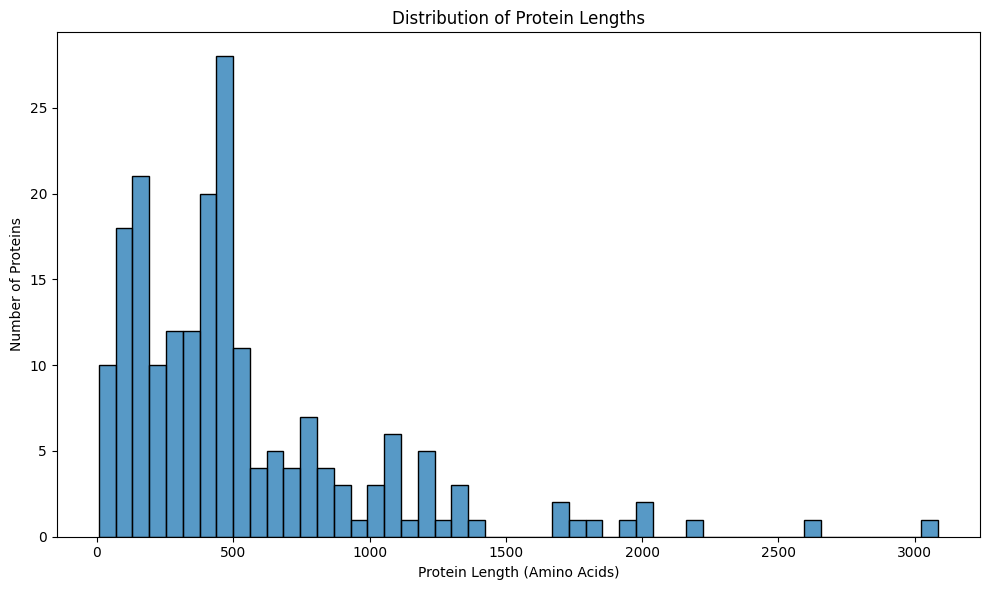

In [65]:
# Visualisation

plt.figure(
    figsize=(10,6)
)


sns.histplot(
    proteins_df["length"],
    bins=50
)


plt.title(
    "Distribution of Protein Lengths"
)


plt.xlabel(
    "Protein Length (Amino Acids)"
)


plt.ylabel(
    "Number of Proteins"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "protein_length_distribution.png"
    ),
    dpi=300
)


plt.show()

In [66]:
# 11. Explore Protein Sequence Characteristics

proteins_df["sequence_length_check"] = (
    proteins_df["sequence"]
    .str.len()
)


display(
    proteins_df[
        [
            "uniprot_id",
            "length",
            "sequence_length_check"
        ]
    ]
    .head()
)

,uniprot_id,length,sequence_length_check
0,A0A1Y8EK52,7,7
1,A0A7P0PKG8,308,308
2,A0A1B0GU82,70,70
3,A0A6Q8PGD2,1307,1307
4,P31645,630,630


In [67]:
# Check consistency

sequence_difference = (
    proteins_df["length"]
    -
    proteins_df["sequence_length_check"]
)


print(
    "Number of inconsistent sequence lengths:",
    (sequence_difference != 0).sum()
)

Number of inconsistent sequence lengths: 0


In [68]:
# 12. Prepare Protein Sequences for Embedding Generation

fasta_output = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_sequences.fasta"
)


with open(
    fasta_output,
    "w"
) as f:

    for _, row in proteins_df.iterrows():

        f.write(
            f">{row['uniprot_id']}\n"
        )

        f.write(
            f"{row['sequence']}\n"
        )


print(
    "FASTA file created successfully."
)

FASTA file created successfully.


In [69]:
# 13. Save Processed Protein Data

processed_file = os.path.join(
    PROCESSED_DATA_PATH,
    "protein_cleaned.csv"
)


proteins_df.to_csv(
    processed_file,
    index=False
)


print(
    "Processed protein dataset saved successfully."
)

Processed protein dataset saved successfully.


In [70]:
# 14. Download Processed Files

from google.colab import files

files.download(processed_file)
files.download(fasta_output)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary of Findings

This notebook analysed the protein information dataset associated with
depression-related genes.

The analysis explored protein identifiers, amino acid sequences, and protein
length characteristics while also assessing data quality issues such as missing
values and duplicate records.

Protein sequences were prepared in FASTA format to support future protein
embedding generation and downstream machine learning analysis.

The processed protein information generated from this notebook will be used in
the following stages of the project, including structural analysis and
drug-target interaction modelling.